# Tutorial 02 — Duality, KKT, Mixed-Integer Decisions and Relaxations

> **What can the mathematical structure of an optimization problem tell us
> about its solution?**

## Where we are

```text
ED → >> UC << → DC-OPF → AC-OPF → SOCP → multi-period → uncertainty
               → Benders → column generation → capstone
      ^
      YOU ARE HERE
```

## Learning objectives

1. State the dual of an LP and interpret its variables as **prices**;
2. use weak and strong duality to bound an optimum without solving it;
3. write the **KKT conditions** and verify them numerically;
4. read complementary slackness as "either the constraint binds or its price
   is zero";
5. formulate unit commitment as a **MILP** and explain where the difficulty
   comes from;
6. solve the **LP relaxation**, recognise it as a lower bound, and measure the
   integrality gap.

## Why this notebook matters more than it looks

Everything later in the course is this notebook again in a different costume.
Benders cuts come from LP duality. The SOC relaxation in Tutorial 05 is the LP
relaxation idea applied to a cone. Column generation prices columns with
reduced costs, which are dual variables. Get this one properly and the second
half of the course is mostly bookkeeping.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo

from psopt_course.config import fast_mode, scaled, set_seed
from psopt_course.metrics import integrality_gap
from psopt_course.networks import two_generator_system
from psopt_course.plotting import COLORS, use_course_style
from psopt_course.solvers import solve

use_course_style()
set_seed()
print(f"reduced (fast) configuration: {fast_mode()}")

reduced (fast) configuration: False


## 1. The primal, in matrix form

Take Tutorial 01's dispatch and write it in the standard form duality theory
likes. With $p = (p_1, p_2)$:

$$
\begin{aligned}
\min_{p \ge 0} \quad & c^\top p \\
\text{s.t.} \quad & \mathbf{1}^\top p = D && [\lambda] \\
& p \le P^{max} && [\mu^{max} \ge 0] \\
& -p \le -P^{min} && [\mu^{min} \ge 0]
\end{aligned}
$$

Each constraint carries a **dual variable** in brackets. The sign conventions
matter and are the usual source of confusion: an equality's dual is free, an
inequality's dual is signed.

In [2]:
system = two_generator_system(demand=100.0)
generators = system.generators
c = np.array([g.c1 for g in generators])
p_min = np.array([g.p_min for g in generators])
p_max = np.array([g.p_max for g in generators])
D = system.total_demand

print(f"c      = {c}")
print(f"p_min  = {p_min}")
print(f"p_max  = {p_max}")
print(f"D      = {D}")

c      = [25. 55.]
p_min  = [20. 10.]
p_max  = [60. 80.]
D      = 100.0


## 2. The dual problem

For the LP above the dual is

$$
\begin{aligned}
\max_{\lambda,\ \mu^{max} \ge 0,\ \mu^{min} \ge 0} \quad
  & \lambda D - {\mu^{max}}^\top P^{max} + {\mu^{min}}^\top P^{min} \\
\text{s.t.} \quad & \lambda - \mu^{max}_g + \mu^{min}_g \le c_g \quad \forall g
\end{aligned}
$$

Read the dual constraint as an economic statement: **no unit may be paid more
than its cost**, after accounting for the scarcity value of its own limits.

### Weak duality

Any feasible dual solution gives a lower bound on the primal optimum:

$$z_{dual} \le z^\star_{primal}.$$

That is the whole engine behind Benders decomposition in Tutorial 08 — and it
holds *for any* dual-feasible point, not only the optimal one.

### Strong duality

For a feasible, bounded LP the two optima coincide: $z_{dual} = z^\star$.
Not every problem class has this property, and the course is careful about
where it does. Tutorial 05 needs Slater's condition for the conic case;
Tutorial 08 needs it again to build valid cuts.

In [3]:
def build_primal(demand: float) -> pyo.ConcreteModel:
    m = pyo.ConcreteModel(name="primal dispatch")
    m.G = pyo.Set(initialize=range(len(generators)))
    m.p = pyo.Var(m.G, domain=pyo.NonNegativeReals)
    m.balance = pyo.Constraint(expr=sum(m.p[g] for g in m.G) == demand)
    m.upper = pyo.Constraint(m.G, rule=lambda m, g: m.p[g] <= p_max[g])
    m.lower = pyo.Constraint(m.G, rule=lambda m, g: m.p[g] >= p_min[g])
    m.cost = pyo.Objective(expr=sum(c[g] * m.p[g] for g in m.G), sense=pyo.minimize)
    return m


def build_dual(demand: float) -> pyo.ConcreteModel:
    """The dual written out explicitly, rather than read off the solver."""
    m = pyo.ConcreteModel(name="dual dispatch")
    m.G = pyo.Set(initialize=range(len(generators)))
    m.lam = pyo.Var(domain=pyo.Reals)                     # free: equality
    m.mu_max = pyo.Var(m.G, domain=pyo.NonNegativeReals)  # signed: inequality
    m.mu_min = pyo.Var(m.G, domain=pyo.NonNegativeReals)

    @m.Constraint(m.G)
    def dual_feasibility(m, g):
        return m.lam - m.mu_max[g] + m.mu_min[g] <= c[g]

    m.obj = pyo.Objective(
        expr=m.lam * demand
        - sum(m.mu_max[g] * p_max[g] for g in m.G)
        + sum(m.mu_min[g] * p_min[g] for g in m.G),
        sense=pyo.maximize,
    )
    return m


primal = build_primal(D)
primal_record = solve(primal, "LP", duals=True)
dual = build_dual(D)
dual_record = solve(dual, "LP")

print(f"primal optimum: {primal_record.objective:,.4f} EUR/h")
print(f"dual   optimum: {dual_record.objective:,.4f} EUR/h")
print(f"strong duality holds: "
      f"{np.isclose(primal_record.objective, dual_record.objective, atol=1e-6)}")
print()
print(f"lambda from the explicit dual : {pyo.value(dual.lam):,.4f} EUR/MWh")
print(f"lambda from the solver's duals: {primal.dual[primal.balance]:,.4f} EUR/MWh")

primal optimum: 3,700.0000 EUR/h
dual   optimum: 3,700.0000 EUR/h
strong duality holds: True

lambda from the explicit dual : 55.0000 EUR/MWh
lambda from the solver's duals: 55.0000 EUR/MWh


## 3. The Lagrangian and the KKT conditions

Attach a multiplier to every constraint and fold them into the objective:

$$
L(p, \lambda, \mu) = c^\top p
  + \lambda\,(D - \mathbf{1}^\top p)
  + {\mu^{max}}^\top (p - P^{max})
  + {\mu^{min}}^\top (P^{min} - p)
$$

At an optimum the **KKT conditions** hold:

| condition | statement |
|---|---|
| stationarity | $\nabla_p L = 0 \;\Rightarrow\; c_g - \lambda + \mu^{max}_g - \mu^{min}_g = 0$ |
| primal feasibility | $\mathbf{1}^\top p = D$, $P^{min} \le p \le P^{max}$ |
| dual feasibility | $\mu^{max}, \mu^{min} \ge 0$ |
| complementary slackness | $\mu^{max}_g (p_g - P^{max}_g) = 0$, $\mu^{min}_g (P^{min}_g - p_g) = 0$ |

Complementary slackness is the one worth saying in words:

> **Either a constraint is binding, or its price is zero.**

A generator that is not at its limit has no scarcity value. A generator pinned
at its ceiling does, and that value is exactly how much the system would save
if the ceiling moved by one MW.

Let us check all four numerically.

In [4]:
p_star = np.array([pyo.value(primal.p[g]) for g in primal.G])
lam_star = primal.dual[primal.balance]
mu_max_star = np.array([-primal.dual[primal.upper[g]] for g in primal.G])
mu_min_star = np.array([primal.dual[primal.lower[g]] for g in primal.G])

checks = pd.DataFrame(
    {
        "p*": p_star,
        "mu_max": mu_max_star,
        "mu_min": mu_min_star,
        "stationarity residual": c - lam_star + mu_max_star - mu_min_star,
        "CS upper": mu_max_star * (p_star - p_max),
        "CS lower": mu_min_star * (p_min - p_star),
    },
    index=[g.name for g in generators],
)
display(checks.round(8))
print(f"lambda* = {lam_star:.4f} EUR/MWh")
print(f"\nmax |stationarity|        : {np.abs(checks['stationarity residual']).max():.2e}")
print(f"max |complementary slack| : "
      f"{max(np.abs(checks['CS upper']).max(), np.abs(checks['CS lower']).max()):.2e}")
print(f"dual feasibility (mu >= 0): {(mu_max_star >= -1e-9).all() and (mu_min_star >= -1e-9).all()}")

,p*,mu_max,mu_min,stationarity residual,CS upper,CS lower
G1_coal,60.0,30.0,-0.0,0.0,0.0,0.0
G2_gas,40.0,0.0,-0.0,0.0,-0.0,0.0


lambda* = 55.0000 EUR/MWh

max |stationarity|        : 0.00e+00
max |complementary slack| : 0.00e+00
dual feasibility (mu >= 0): True


## 4. Discrete decisions: unit commitment

So far a unit could produce any amount down to zero. Real units cannot: below
a technical minimum they must be **off**, and starting one costs money. That
needs a binary variable:

$$u_{g,t} \in \{0, 1\} \quad \text{(is unit } g \text{ running in period } t?)$$

and the limits become *conditional*:

$$u_{g,t}\,P^{min}_g \;\le\; p_{g,t} \;\le\; u_{g,t}\,P^{max}_g$$

which is the key trick: when $u = 0$ both sides collapse to zero and the unit
is forced off; when $u = 1$ the original limits return.

Start-up is detected with an indicator:

$$v_{g,t} \ge u_{g,t} - u_{g,t-1}, \qquad v_{g,t} \ge 0$$

### Problem class

Linear objective, linear constraints, **some variables integer** — a
**mixed-integer linear program (MILP)**.

In [5]:
def unit_commitment(demand_profile, *, relax: bool = False) -> pyo.ConcreteModel:
    """Multi-period unit commitment.

    With ``relax=True`` the binaries become continuous on [0, 1]. Everything
    else is identical — which is what makes the two objectives comparable, and
    the difference attributable to integrality alone.
    """
    m = pyo.ConcreteModel(name="unit commitment")
    m.G = pyo.Set(initialize=range(len(generators)))
    m.T = pyo.Set(initialize=range(len(demand_profile)), ordered=True)
    m.demand = pyo.Param(m.T, initialize=dict(enumerate(demand_profile)))

    domain = pyo.UnitInterval if relax else pyo.Binary
    m.u = pyo.Var(m.G, m.T, domain=domain)          # on/off
    m.v = pyo.Var(m.G, m.T, domain=pyo.NonNegativeReals)  # start-up indicator
    m.p = pyo.Var(m.G, m.T, domain=pyo.NonNegativeReals)

    @m.Constraint(m.T)
    def balance(m, t):
        return sum(m.p[g, t] for g in m.G) == m.demand[t]

    @m.Constraint(m.G, m.T)
    def min_output(m, g, t):
        return m.p[g, t] >= p_min[g] * m.u[g, t]

    @m.Constraint(m.G, m.T)
    def max_output(m, g, t):
        return m.p[g, t] <= p_max[g] * m.u[g, t]

    @m.Constraint(m.G, m.T)
    def startup(m, g, t):
        if t == m.T.first():
            return m.v[g, t] >= m.u[g, t] - 0      # assume off before the horizon
        return m.v[g, t] >= m.u[g, t] - m.u[g, m.T.prev(t)]

    m.cost = pyo.Objective(
        expr=sum(c[g] * m.p[g, t] for g in m.G for t in m.T)
        + sum(generators[g].start_cost * m.v[g, t] for g in m.G for t in m.T),
        sense=pyo.minimize,
    )
    return m


n_periods = scaled(full=12, fast=6)
profile = 40.0 + 60.0 * np.sin(np.linspace(0, np.pi, n_periods)) ** 2
print(f"{n_periods} periods, demand {profile.min():.1f} - {profile.max():.1f} MW")

milp = unit_commitment(profile)
milp_record = solve(milp, "MILP")
print(f"\nMILP  {milp_record.summary()}")

12 periods, demand 40.0 - 98.8 MW



MILP  MILP  via appsi_highs  optimal      obj=   25,862.0034   0.04s  72 vars (24 binary), 84 cons, gap=0.000%


## 5. The LP relaxation — the idea the whole course runs on

Replace $u \in \{0,1\}$ by $u \in [0,1]$. Every integer point is still
feasible, plus a great many fractional ones:

$$\mathcal{F}_{MILP} \subseteq \mathcal{F}_{LP}$$

A larger feasible set cannot have a worse optimum, so for a minimization

$$z_{LP} \;\le\; z_{MILP}.$$

**The LP relaxation is a lower bound.** It is also, usually, physically
nonsense — a unit 0.4 switched on does not exist. Both facts are true at once,
and holding them together is the single most transferable idea in this course.

In [6]:
relaxed = unit_commitment(profile, relax=True)
relaxed_record = solve(relaxed, "LP")

print(f"LP relaxation : {relaxed_record.objective:,.2f} EUR   (lower bound)")
print(f"MILP optimum  : {milp_record.objective:,.2f} EUR   (achievable)")
print(f"integrality gap: {integrality_gap(milp_record.objective, relaxed_record.objective):.3%}")

fractional = [
    (g, t, pyo.value(relaxed.u[g, t]))
    for g in relaxed.G for t in relaxed.T
    if 1e-6 < pyo.value(relaxed.u[g, t]) < 1 - 1e-6
]
print(f"\nfractional commitments in the relaxation: {len(fractional)}")
for g, t, value in fractional[:4]:
    print(f"  u[{generators[g].name}, t={t}] = {value:.4f}  <- not a physical state")

LP relaxation : 25,784.72 EUR   (lower bound)
MILP optimum  : 25,862.00 EUR   (achievable)
integrality gap: 0.299%

fractional commitments in the relaxation: 11
  u[G1_coal, t=0] = 0.6667  <- not a physical state
  u[G1_coal, t=1] = 0.7460  <- not a physical state
  u[G1_coal, t=9] = 0.9590  <- not a physical state
  u[G1_coal, t=10] = 0.7460  <- not a physical state


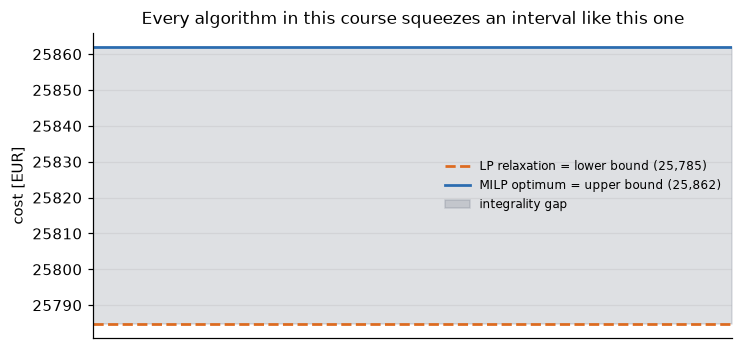

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.axhline(relaxed_record.objective, color=COLORS["relaxed"], ls="--",
           label=f"LP relaxation = lower bound ({relaxed_record.objective:,.0f})")
ax.axhline(milp_record.objective, color=COLORS["feasible"],
           label=f"MILP optimum = upper bound ({milp_record.objective:,.0f})")
ax.fill_between([0, 1], relaxed_record.objective, milp_record.objective,
                alpha=0.18, color=COLORS["neutral"], label="integrality gap")
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_ylabel("cost [EUR]")
ax.set_title("Every algorithm in this course squeezes an interval like this one")
ax.legend(fontsize=8, loc="center right")
plt.show()

## 6. Exercises

---

### Exercise 2.1 — Verify strong duality and read the prices

**Difficulty:** Basic

#### Your task

For three demand levels — 60, 100 and 135 MW —

1. solve the primal and the explicit dual;
2. check that the two objectives agree;
3. record $\lambda$, and say which generator is marginal at each level.

#### Expected result

The two objectives should agree to solver tolerance every time. $\lambda$
should equal the marginal cost of whichever unit still has room to move.

#### Hint

`build_primal(demand)` and `build_dual(demand)` are already defined.

In [8]:
demand_levels = [60.0, 100.0, 135.0]

rows = []
for demand in demand_levels:
    pm = build_primal(demand)
    pr = solve(pm, "LP", duals=True)
    dm = build_dual(demand)
    dr = solve(dm, "LP")
    outputs = [pyo.value(pm.p[g]) for g in pm.G]
    marginal = next(
        (generators[g].name for g in pm.G
         if p_min[g] + 1e-6 < outputs[g] < p_max[g] - 1e-6),
        "none — every unit is at a limit",
    )
    rows.append({
        "demand": demand, "primal": pr.objective, "dual": dr.objective,
        "lambda": pm.dual[pm.balance], "marginal unit": marginal,
    })

duality = pd.DataFrame(rows).set_index("demand")
display(duality.round(4))

,primal,dual,lambda,marginal unit
demand,,,,
60.0,1800.0,1800.0,25.0,G1_coal
100.0,3700.0,3700.0,55.0,G2_gas
135.0,5625.0,5625.0,55.0,G2_gas


In [9]:
assert duality is not None, "build the `duality` DataFrame first"
_diff = (duality["primal"] - duality["dual"]).abs().max()
assert _diff < 1e-5, f"strong duality fails by {_diff:.3e} — check the dual formulation"
print(f"Check passed: primal and dual agree to {_diff:.2e} at every demand.")

Check passed: primal and dual agree to 0.00e+00 at every demand.


#### Interpretation

**What does $\lambda$ mean, and why does it change in steps?**

In [10]:
print("ANSWER.")
print()
print("lambda is the SHADOW PRICE of the power balance: the rate at which the")
print("optimal cost changes per extra MW of demand. Formally it is the partial")
print("derivative of the optimal value with respect to the right-hand side.")
print()
print("It moves in steps because it is set by whichever unit is MARGINAL — the")
print("one that still has room to respond. That unit is determined by the set of")
print("ACTIVE constraints, and an active set is a discrete object: it changes")
print("only when a constraint starts or stops binding.")
print()
print("Between those switch points the active set is constant, so lambda is")
print("constant too. That is also why a linear dispatch has a piecewise-constant")
print("price while the quadratic one in Tutorial 01 had a continuous price: with")
print("a strictly convex cost the marginal cost moves continuously with output.")

ANSWER.

lambda is the SHADOW PRICE of the power balance: the rate at which the
optimal cost changes per extra MW of demand. Formally it is the partial
derivative of the optimal value with respect to the right-hand side.

It moves in steps because it is set by whichever unit is MARGINAL — the
one that still has room to respond. That unit is determined by the set of
ACTIVE constraints, and an active set is a discrete object: it changes
only when a constraint starts or stops binding.

Between those switch points the active set is constant, so lambda is
constant too. That is also why a linear dispatch has a piecewise-constant
price while the quadratic one in Tutorial 01 had a continuous price: with
a strictly convex cost the marginal cost moves continuously with output.


---

### Exercise 2.2 — Verify the KKT conditions yourself

**Difficulty:** Intermediate

#### Your task

Write `check_kkt(model)` that, for a solved primal, returns a dict with the
worst violation of each of the four KKT conditions:

`{"stationarity": ..., "primal_feasibility": ..., "dual_feasibility": ...,
  "complementary_slackness": ...}`

Then run it at a demand where the cheap unit is **not** at a limit, and one
where it **is**, and compare the multipliers.

#### Expected result

All four residuals near machine precision in both cases. The multipliers
should differ: a non-binding limit must have a zero price.

#### Hint

Pyomo's sign convention for `model.dual` on a `<=` constraint is the negative
of the textbook $\mu^{max} \ge 0$; section 3 above shows the fix.

In [11]:
def check_kkt(model) -> dict:
    """Worst violation of each KKT condition for a solved dispatch."""
    p = np.array([pyo.value(model.p[g]) for g in model.G])
    lam = model.dual[model.balance]
    mu_max = np.array([-model.dual[model.upper[g]] for g in model.G])
    mu_min = np.array([model.dual[model.lower[g]] for g in model.G])

    stationarity = np.abs(c - lam + mu_max - mu_min).max()
    balance_error = abs(p.sum() - pyo.value(model.balance.upper))
    bound_error = max(
        float(np.maximum(p - p_max, 0).max()), float(np.maximum(p_min - p, 0).max())
    )
    primal_feasibility = max(balance_error, bound_error)
    dual_feasibility = max(
        float(np.maximum(-mu_max, 0).max()), float(np.maximum(-mu_min, 0).max())
    )
    complementary = max(
        float(np.abs(mu_max * (p - p_max)).max()),
        float(np.abs(mu_min * (p_min - p)).max()),
    )
    return {
        "stationarity": stationarity,
        "primal_feasibility": primal_feasibility,
        "dual_feasibility": dual_feasibility,
        "complementary_slackness": complementary,
        "lambda": lam,
        "mu_max": mu_max.copy(),
        "mu_min": mu_min.copy(),
    }


kkt_results = {}
for label, demand in [("cheap unit interior", 70.0), ("cheap unit at ceiling", 130.0)]:
    m = build_primal(demand)
    solve(m, "LP", duals=True)
    kkt_results[label] = check_kkt(m)
    r = kkt_results[label]
    print(f"--- {label} (D = {demand:.0f} MW) ---")
    print(f"  p*      = {[round(pyo.value(m.p[g]), 2) for g in m.G]}")
    print(f"  lambda  = {r['lambda']:.4f}")
    print(f"  mu_max  = {r['mu_max'].round(4)}")
    for key in ("stationarity", "primal_feasibility", "dual_feasibility",
                "complementary_slackness"):
        print(f"  {key:24s} {r[key]:.2e}")
    print()

--- cheap unit interior (D = 70 MW) ---
  p*      = [60.0, 10.0]
  lambda  = 55.0000
  mu_max  = [30.  0.]
  stationarity             0.00e+00
  primal_feasibility       0.00e+00
  dual_feasibility         0.00e+00
  complementary_slackness  0.00e+00



--- cheap unit at ceiling (D = 130 MW) ---
  p*      = [60.0, 70.0]
  lambda  = 55.0000
  mu_max  = [30.  0.]
  stationarity             0.00e+00
  primal_feasibility       0.00e+00
  dual_feasibility         0.00e+00
  complementary_slackness  0.00e+00



In [12]:
assert kkt_results, "run check_kkt at both demand levels first"
for _label, _r in kkt_results.items():
    for _key in ("stationarity", "primal_feasibility", "dual_feasibility",
                 "complementary_slackness"):
        assert _r[_key] < 1e-6, f"{_label}: {_key} violated by {_r[_key]:.3e}"
print("Checks passed: all four KKT conditions hold at both operating points.")

Checks passed: all four KKT conditions hold at both operating points.


#### Interpretation

**What did complementary slackness tell you about the two cases?**

In [13]:
interior = kkt_results["cheap unit interior"]
binding = kkt_results["cheap unit at ceiling"]
print("ANSWER.")
print()
print(f"Interior case: mu_max = {interior['mu_max'].round(4)} — all zero, because")
print("no upper limit is binding. A constraint that is not active has no price.")
print()
print(f"Binding case:  mu_max = {binding['mu_max'].round(4)} — the cheap unit's")
print("ceiling now carries a strictly positive price. Its value is exactly what")
print("the system would save per extra MW of capacity on that unit:")
print(f"  {binding['mu_max'].max():.2f} EUR/MWh = "
      f"{binding['lambda']:.2f} (price) - {c[0]:.2f} (its cost)")
print()
print("That is complementary slackness read forwards: mu * slack = 0 means one of")
print("the two must vanish. It is also precisely the information a Benders cut")
print("carries in Tutorial 08 — which constraints were binding, and how much they")
print("were worth.")

ANSWER.

Interior case: mu_max = [30.  0.] — all zero, because
no upper limit is binding. A constraint that is not active has no price.

Binding case:  mu_max = [30.  0.] — the cheap unit's
ceiling now carries a strictly positive price. Its value is exactly what
the system would save per extra MW of capacity on that unit:
  30.00 EUR/MWh = 55.00 (price) - 25.00 (its cost)

That is complementary slackness read forwards: mu * slack = 0 means one of
the two must vanish. It is also precisely the information a Benders cut
carries in Tutorial 08 — which constraints were binding, and how much they
were worth.


---

### Exercise 2.3 — How does the integrality gap behave?

**Difficulty:** Intermediate

The LP relaxation is a lower bound, but how *good* a bound? It depends on the
instance, and start-up costs are the usual culprit.

#### Your task

1. Sweep the start-up cost of the cheap unit over `startup_sweep`.
2. For each value solve both the MILP and its LP relaxation.
3. Plot both objectives and the integrality gap.

#### Expected result

With no start-up cost the relaxation should be tight or nearly so. As the
start-up cost rises the gap should widen — the relaxation can buy a *fraction*
of a start-up, and the MILP cannot.

#### Hint

`generators[0].start_cost` is frozen; rebuild the system with
`dataclasses.replace` or edit the module-level list carefully.

,MILP,LP relaxation,integrality gap
start cost,,,
0.0,25362.0034,25284.7249,0.0030
250.0,25612.0034,25534.7249,0.0030
500.0,25862.0034,25784.7249,0.0030
1000.0,26362.0034,26284.7249,0.0029
2000.0,27362.0034,27284.7249,0.0028


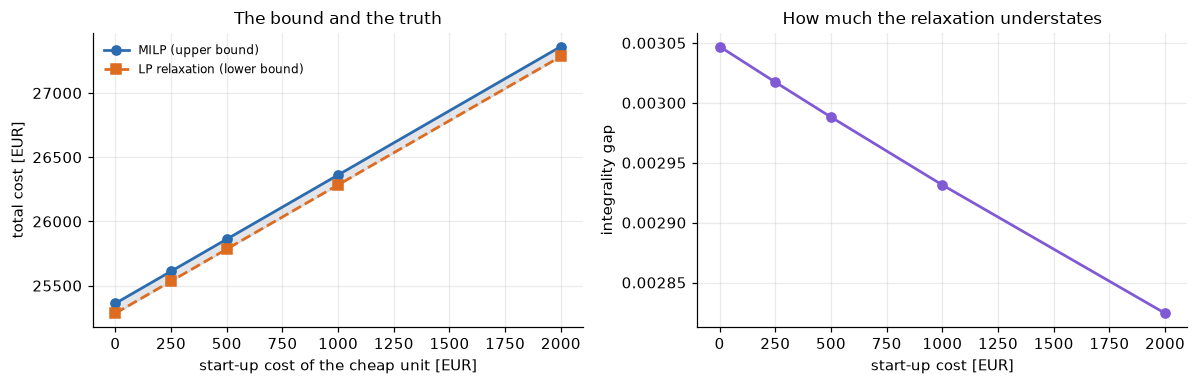

In [14]:
import dataclasses

startup_sweep = [0.0, 250.0, 500.0, 1000.0, 2000.0]
original = list(generators)

rows = []
for start_cost in startup_sweep:
    generators[0] = dataclasses.replace(original[0], start_cost=start_cost)
    milp_i = unit_commitment(profile)
    lp_i = unit_commitment(profile, relax=True)
    z_milp = solve(milp_i, "MILP").objective
    z_lp = solve(lp_i, "LP").objective
    rows.append({
        "start cost": start_cost, "MILP": z_milp, "LP relaxation": z_lp,
        "integrality gap": integrality_gap(z_milp, z_lp),
    })
generators[0] = original[0]   # put it back

gap_sweep = pd.DataFrame(rows).set_index("start cost")
display(gap_sweep.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(gap_sweep.index, gap_sweep["MILP"], "o-", label="MILP (upper bound)",
             color=COLORS["feasible"])
axes[0].plot(gap_sweep.index, gap_sweep["LP relaxation"], "s--",
             label="LP relaxation (lower bound)", color=COLORS["relaxed"])
axes[0].fill_between(gap_sweep.index, gap_sweep["LP relaxation"], gap_sweep["MILP"],
                     alpha=0.15, color=COLORS["neutral"])
axes[0].set_xlabel("start-up cost of the cheap unit [EUR]")
axes[0].set_ylabel("total cost [EUR]")
axes[0].set_title("The bound and the truth")
axes[0].legend(fontsize=8)

axes[1].plot(gap_sweep.index, gap_sweep["integrality gap"], "o-", color=COLORS["accent"])
axes[1].set_xlabel("start-up cost [EUR]")
axes[1].set_ylabel("integrality gap")
axes[1].set_title("How much the relaxation understates")
fig.tight_layout()
plt.show()

In [15]:
assert gap_sweep is not None, "build the `gap_sweep` DataFrame first"
assert (gap_sweep["LP relaxation"] <= gap_sweep["MILP"] + 1e-6).all(), (
    "the LP relaxation must never exceed the MILP optimum — it is a LOWER bound"
)
assert (gap_sweep["integrality gap"] >= -1e-9).all()
print("Check passed: the relaxation is a valid lower bound at every start-up cost.")

Check passed: the relaxation is a valid lower bound at every start-up cost.


#### Interpretation

**Why does the gap widen, and what would you do about it?**

In [16]:
print("ANSWER.")
print()
print("The relaxation widens because start-up cost is the one term the fractional")
print("solution can cheat on. Setting u = 0.4 buys 40% of a start-up for 40% of")
print("the money, and no such thing exists. With zero start-up cost there is")
print(f"nothing to cheat on and the gap is {gap_sweep['integrality gap'].iloc[0]:.2%};")
print(f"at {startup_sweep[-1]:.0f} EUR it has grown to "
      f"{gap_sweep['integrality gap'].iloc[-1]:.2%}.")
print()
print("What to do about it is the whole business of MILP formulation. The gap is")
print("a property of the FORMULATION, not of the problem: two models of the same")
print("unit commitment can have very different relaxations, and the tighter one is")
print("usually worth solving even if it has more constraints. Tighter big-M values,")
print("and adding valid inequalities the integer solutions satisfy but fractional")
print("ones do not, both shrink it.")
print()
print("This matters because branch-and-bound PROVES optimality by closing exactly")
print("this gap. A weak relaxation means a deep search tree.")

ANSWER.

The relaxation widens because start-up cost is the one term the fractional
solution can cheat on. Setting u = 0.4 buys 40% of a start-up for 40% of
the money, and no such thing exists. With zero start-up cost there is
nothing to cheat on and the gap is 0.30%;
at 2000 EUR it has grown to 0.28%.

What to do about it is the whole business of MILP formulation. The gap is
a property of the FORMULATION, not of the problem: two models of the same
unit commitment can have very different relaxations, and the tighter one is
usually worth solving even if it has more constraints. Tighter big-M values,
and adding valid inequalities the integer solutions satisfy but fractional
ones do not, both shrink it.

This matters because branch-and-bound PROVES optimality by closing exactly
this gap. A weak relaxation means a deep search tree.


---

### Exercise 2.4 — Does a MILP solver enumerate? (research-style)

**Difficulty:** Advanced

A common belief is that MILP solvers try all $2^n$ binary combinations. If
that were true, a 12-period two-unit problem would need $2^{24} \approx 1.7$
million solves.

#### Your task

1. Solve the commitment for increasing horizon lengths.
2. Record the solve time and the number of binaries.
3. Compare the growth against $2^{n}$.
4. State what branch-and-bound is doing instead.

#### Expected result

Solve time should grow far more slowly than $2^n$. You are watching *pruning*:
whole subtrees are discarded without being explored, because their LP bound is
already worse than a known feasible solution.

In [17]:
horizons = [4, 8, 12, 16] if not fast_mode() else [4, 6, 8]

rows = []
for horizon in horizons:
    prof = 40.0 + 60.0 * np.sin(np.linspace(0, np.pi, horizon)) ** 2
    m = unit_commitment(prof)
    rec = solve(m, "MILP")
    rows.append({
        "periods": horizon, "binaries": rec.n_binary,
        "2^binaries": float(2.0 ** rec.n_binary),
        "seconds": rec.seconds, "objective": rec.objective,
    })

scaling = pd.DataFrame(rows).set_index("periods")
display(scaling.assign(**{"2^binaries": scaling["2^binaries"].map("{:.3g}".format)}).round(4))

print()
print(f"binaries grew {scaling['binaries'].iloc[0]:.0f} -> {scaling['binaries'].iloc[-1]:.0f}, "
      f"so brute force would grow by a factor of "
      f"{2.0 ** (scaling['binaries'].iloc[-1] - scaling['binaries'].iloc[0]):.3g}.")
print(f"measured time grew by a factor of "
      f"{scaling['seconds'].iloc[-1] / max(scaling['seconds'].iloc[0], 1e-6):.1f}.")

,binaries,2^binaries,seconds,objective
periods,,,,
4,8,256,0.0241,8400.0000
8,16,6.55e+04,0.0230,17122.2816
12,24,1.68e+07,0.0249,25862.0034
16,32,4.29e+09,0.0289,35205.0475



binaries grew 8 -> 32, so brute force would grow by a factor of 1.68e+07.
measured time grew by a factor of 1.2.


In [18]:
assert scaling is not None, "build the `scaling` table first"
assert (scaling["binaries"] > 0).all(), "these should be MILPs, with binaries"
_brute = 2.0 ** (scaling["binaries"].iloc[-1] - scaling["binaries"].iloc[0])
_actual = scaling["seconds"].iloc[-1] / max(scaling["seconds"].iloc[0], 1e-6)
assert _actual < _brute, "solve time should grow far slower than 2^n"
print("Check passed: growth is nowhere near exponential enumeration.")

Check passed: growth is nowhere near exponential enumeration.


#### Interpretation

**So what is branch-and-bound actually doing?**

In [19]:
print("ANSWER. It is enumerating, but it is enumerating a tree it mostly refuses")
print("to build.")
print()
print("At each node it solves an LP RELAXATION, which gives a lower bound on")
print("everything below that node. If that bound is already worse than the best")
print("integer solution found so far — the INCUMBENT, an upper bound — then no")
print("descendant can improve on the incumbent and the whole subtree is discarded")
print("without ever being explored. That is pruning by bound, and it is why the")
print("measured growth above is nothing like 2^n.")
print()
print("So the two bounds from section 5 are not decoration; they ARE the")
print("algorithm:")
print("   LP relaxation at a node -> lower bound -> can I prune?")
print("   integer solution found  -> upper bound -> incumbent to prune against")
print("and the solver stops when they meet, which is what a reported 'MIP gap' of")
print("0% means.")
print()
print("This is also why Exercise 2.3 matters. A weak relaxation gives weak bounds,")
print("prunes less, and leaves a much bigger tree to explore. Tightening a")
print("formulation is not cosmetic — it is the difference between seconds and days.")

ANSWER. It is enumerating, but it is enumerating a tree it mostly refuses
to build.

At each node it solves an LP RELAXATION, which gives a lower bound on
everything below that node. If that bound is already worse than the best
integer solution found so far — the INCUMBENT, an upper bound — then no
descendant can improve on the incumbent and the whole subtree is discarded
without ever being explored. That is pruning by bound, and it is why the
measured growth above is nothing like 2^n.

So the two bounds from section 5 are not decoration; they ARE the
algorithm:
   LP relaxation at a node -> lower bound -> can I prune?
   integer solution found  -> upper bound -> incumbent to prune against
and the solver stops when they meet, which is what a reported 'MIP gap' of
0% means.

This is also why Exercise 2.3 matters. A weak relaxation gives weak bounds,
prunes less, and leaves a much bigger tree to explore. Tightening a
formulation is not cosmetic — it is the difference between seconds and 

## 7. Key takeaways

1. **Every constraint has a price.** The dual variable of the power balance is
   the marginal cost of serving load; the dual of a capacity limit is the
   marginal value of that capacity.
2. **Weak duality bounds without solving.** *Any* dual-feasible point gives a
   valid lower bound — which is exactly what Benders exploits.
3. **Complementary slackness:** either a constraint binds or its price is zero.
4. **Relaxation enlarges the feasible set**, so for a minimization it gives a
   lower bound — and a solution that need not be physically meaningful.
5. **The integrality gap is a property of the formulation**, and it is what
   branch-and-bound has to close.
6. **MILP solvers do not enumerate.** They prune with bounds.

## Further reading

- Boyd & Vandenberghe, *Convex Optimization*, CUP 2004 — chapter 5 on duality
  and KKT.
- Bertsimas & Tsitsiklis, *Introduction to Linear Optimization*, Athena 1997.
- Morales-España, Latorre & Ramos, "Tight and compact MILP formulation for the
  thermal unit commitment problem", *IEEE Trans. Power Syst.* 28(4), 2013 —
  the formulation-tightness point of Exercise 2.3, done properly.

## Next

Tutorial 03 puts the generators on a network. The balance constraint becomes
one equation per bus, lines get limits, and the single price $\lambda$ splits
into a different price at every node.